## Loading OEWS Dataset

This dataset includes the Occupational Employment and Wage Statistics data from the Bureau of Labor Statistics website. 

### Loading libraries

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(Path("C:\\Users\\patel\\Python\\oews_data_yearly\\all_data_M_2025.csv"),
                thousands=",", 
                 na_values=["#", "*", "**"], 
                 low_memory=False)

df

,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,24.51,38.71,61.81,31200.0,37590.0,50980.0,80520.0,128560.0,NaN,NaN
1,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,60.83,84.75,123.71,60130.0,82970.0,126520.0,176280.0,257310.0,NaN,NaN
2,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1000,Top Executives,...,52.17,82.85,134.48,50480.0,73260.0,108510.0,172330.0,279710.0,NaN,NaN
3,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1010,Chief Executives,...,102.88,171.25,244.10,75700.0,129540.0,213990.0,356200.0,507730.0,NaN,NaN
4,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,102.88,171.25,244.10,75700.0,129540.0,213990.0,356200.0,507730.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413522,7800001,Virgin Islands,6,VI,000000,Cross-industry,cross-industry,1235,53-7051,Industrial Truck and Tractor Operators,...,16.94,20.88,25.29,27190.0,31030.0,35230.0,43420.0,52600.0,NaN,NaN
413523,7800001,Virgin Islands,6,VI,000000,Cross-industry,cross-industry,1235,53-7061,Cleaners of Vehicles and Equipment,...,13.60,14.99,17.60,22230.0,26360.0,28290.0,31190.0,36610.0,NaN,NaN
413524,7800001,Virgin Islands,6,VI,000000,Cross-industry,cross-industry,1235,53-7062,"Laborers and Freight, Stock, and Material Move...",...,15.30,17.99,18.72,26620.0,28150.0,31810.0,37410.0,38940.0,NaN,NaN
413525,7800001,Virgin Islands,6,VI,000000,Cross-industry,cross-industry,1235,53-7064,"Packers and Packagers, Hand",...,11.00,13.08,17.07,21890.0,21960.0,22880.0,27200.0,35510.0,NaN,NaN


### Summary Statistics (Numerical Columns)

In [3]:
#Columns 'AREA', 'AREA_TYPE', 'NAICS', and 'OWN_CODE' look numerical but are actually categorical. Therefore, they will not be included for the numerical statistics.

NUMERIC_COLS = [
    "TOT_EMP", "EMP_PRSE", "JOBS_1000", "LOC_QUOTIENT", "PCT_TOTAL", "PCT_RPT",
    "H_MEAN", "A_MEAN", "MEAN_PRSE",
    "H_PCT10", "H_PCT25", "H_MEDIAN", "H_PCT75", "H_PCT90",
    "A_PCT10", "A_PCT25", "A_MEDIAN", "A_PCT75", "A_PCT90",
]
df[NUMERIC_COLS] = df[NUMERIC_COLS].apply(pd.to_numeric, errors="coerce")
df[NUMERIC_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
TOT_EMP,397467.0,13235.517942,371287.976433,30.000,100.000,330.000,1600.000,1.554957e+08
EMP_PRSE,397467.0,12.334297,10.463132,0.000,4.600,9.300,17.100,4.990000e+01
JOBS_1000,231103.0,7.396950,51.773450,0.002,0.415,1.062,3.026,1.000000e+03
LOC_QUOTIENT,231103.0,1.366477,2.891495,0.010,0.680,0.980,1.390,3.645300e+02
PCT_TOTAL,159364.0,1.375056,6.742109,0.000,0.030,0.120,0.580,1.000000e+02
PCT_RPT,108670.0,10.573194,15.945899,1.000,1.000,4.000,12.000,1.000000e+02
H_MEAN,392686.0,34.905474,19.601612,8.260,22.310,29.280,41.660,3.417900e+02
A_MEAN,408092.0,72968.981602,40566.664270,17170.000,46740.000,61610.000,87220.000,7.109300e+05
MEAN_PRSE,409074.0,3.586534,3.717605,0.000,1.300,2.400,4.500,2.990000e+01
H_PCT10,392686.0,22.361385,10.105332,7.250,16.110,19.290,25.590,2.027800e+02


### Summary Statistics (Categorical Columns)

In [4]:
CATEGORICAL_LOW_CARD = ["I_GROUP", "O_GROUP", "AREA_TYPE", "OWN_CODE", "PRIM_STATE"]
CATEGORICAL_HIGH_CARD = ["AREA", "AREA_TITLE", "NAICS", "NAICS_TITLE", "OCC_CODE", "OCC_TITLE"]

# full frequency tables — safe because cardinality is small
for col in CATEGORICAL_LOW_CARD:
    print(df[col].value_counts(normalize=True).mul(100).round(1), "\n")

I_GROUP
cross-industry               57.4
4-digit                      20.1
3-digit                       9.4
sector                        4.0
5-digit                       3.7
4-digit, ownership            2.4
cross-industry, ownership     1.4
3-digit, ownership            1.1
6-digit                       0.4
Name: proportion, dtype: float64 

O_GROUP
detailed    74.1
broad       15.0
minor        5.7
major        5.0
total        0.3
Name: proportion, dtype: float64 

AREA_TYPE
1    42.9
4    36.3
6    11.8
2     8.8
3     0.2
Name: proportion, dtype: float64 

OWN_CODE
1235    57.4
5       34.8
235      2.1
2        1.6
3        1.5
57       0.9
123      0.9
1        0.5
58       0.2
59       0.2
Name: proportion, dtype: float64 

PRIM_STATE
US    42.9
CA     3.2
TX     3.2
FL     2.5
PA     2.1
NC     2.0
OH     1.9
NY     1.9
MI     1.9
GA     1.7
WI     1.7
TN     1.5
IN     1.5
AL     1.4
VA     1.3
WA     1.3
MO     1.3
IL     1.3
IA     1.2
LA     1.2
CO     1.2
OR     1.2
S

In [5]:
def categorical_overview(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in cols:
        vc = df[col].value_counts()
        rows.append({
            "column": col,
            "n_unique": df[col].nunique(),
            "top_value": vc.index[0],
            "top_pct": round(vc.iloc[0] / len(df) * 100, 2),
            "n_missing": df[col].isna().sum(),
        })
    return pd.DataFrame(rows)

categorical_overview(df, CATEGORICAL_LOW_CARD + CATEGORICAL_HIGH_CARD)

,column,n_unique,top_value,top_pct,n_missing
0,I_GROUP,9,cross-industry,57.44,0
1,O_GROUP,5,detailed,74.09,0
2,AREA_TYPE,5,1,42.90,0
3,OWN_CODE,10,1235,57.44,0
4,PRIM_STATE,55,US,42.90,0
5,AREA,585,99,42.90,0
6,AREA_TITLE,583,U.S.,42.90,0
7,NAICS,414,000000,57.44,0
8,NAICS_TITLE,394,Cross-industry,57.44,0
9,OCC_CODE,1394,13-1020,0.34,0


In [6]:
df["O_GROUP"].value_counts(normalize=True) * 100


O_GROUP
detailed    74.089721
broad       15.014981
minor        5.668554
major        4.976700
total        0.250044
Name: proportion, dtype: float64

In [7]:
df["I_GROUP"].value_counts(normalize=True) * 100

I_GROUP
cross-industry               57.437846
4-digit                      20.136775
3-digit                       9.380040
sector                        3.962498
5-digit                       3.740505
4-digit, ownership            2.427169
cross-industry, ownership     1.367263
3-digit, ownership            1.103918
6-digit                       0.443986
Name: proportion, dtype: float64

#### Note: Rows are not all at the same level of granularity — O_GROUP and I_GROUP must be filtered before aggregating TOT_EMP or wage columns, or totals will double-count

## Visualizations

### Wage distribution across Occupations

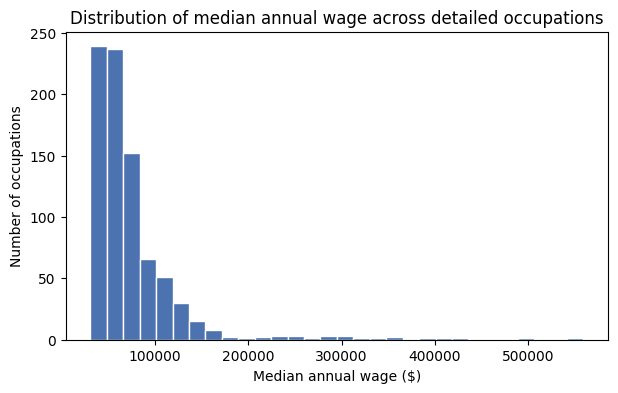

In [8]:
national_detailed = df[
    (df["AREA_TYPE"] == 1) &
    (df["O_GROUP"] == "detailed") &
    (df["I_GROUP"] == "cross-industry")
]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(national_detailed["A_MEDIAN"].dropna(), bins=30, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Median annual wage ($)")
ax.set_ylabel("Number of occupations")
ax.set_title("Distribution of median annual wage across detailed occupations")
plt.show()

### Occupation Rankings by Count

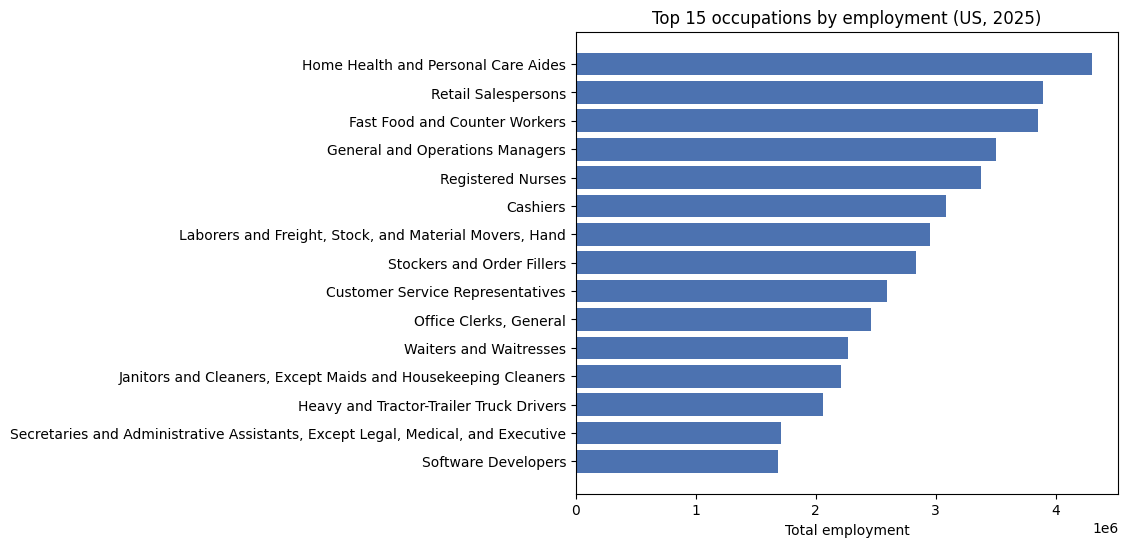

In [9]:
top15 = national_detailed.nlargest(15, "TOT_EMP")

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top15["OCC_TITLE"], top15["TOT_EMP"], color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Total employment")
ax.set_title("Top 15 occupations by employment (US, 2025)")
plt.show()

### Category counts

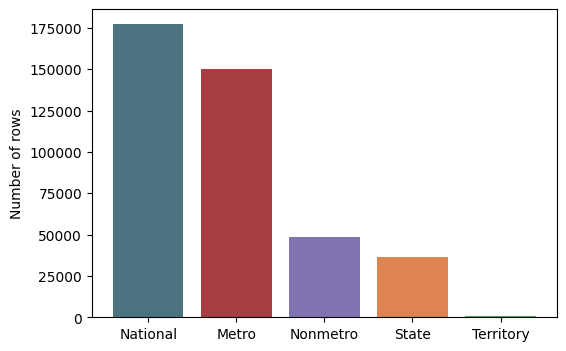

In [10]:
labels = {1: "National", 2: "State", 3: "Territory", 4: "Metro", 6: "Nonmetro"}
counts = df["AREA_TYPE"].map(labels).value_counts()
palette = {"National": "#4C7280", "State": "#DD8452", "Territory": "#55A868",
           "Metro": "#A73F42", "Nonmetro": "#8172B2"}

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color=[palette[c] for c in counts.index])
ax.set_ylabel("Number of rows")
plt.show()

### Wage score VS Occupations

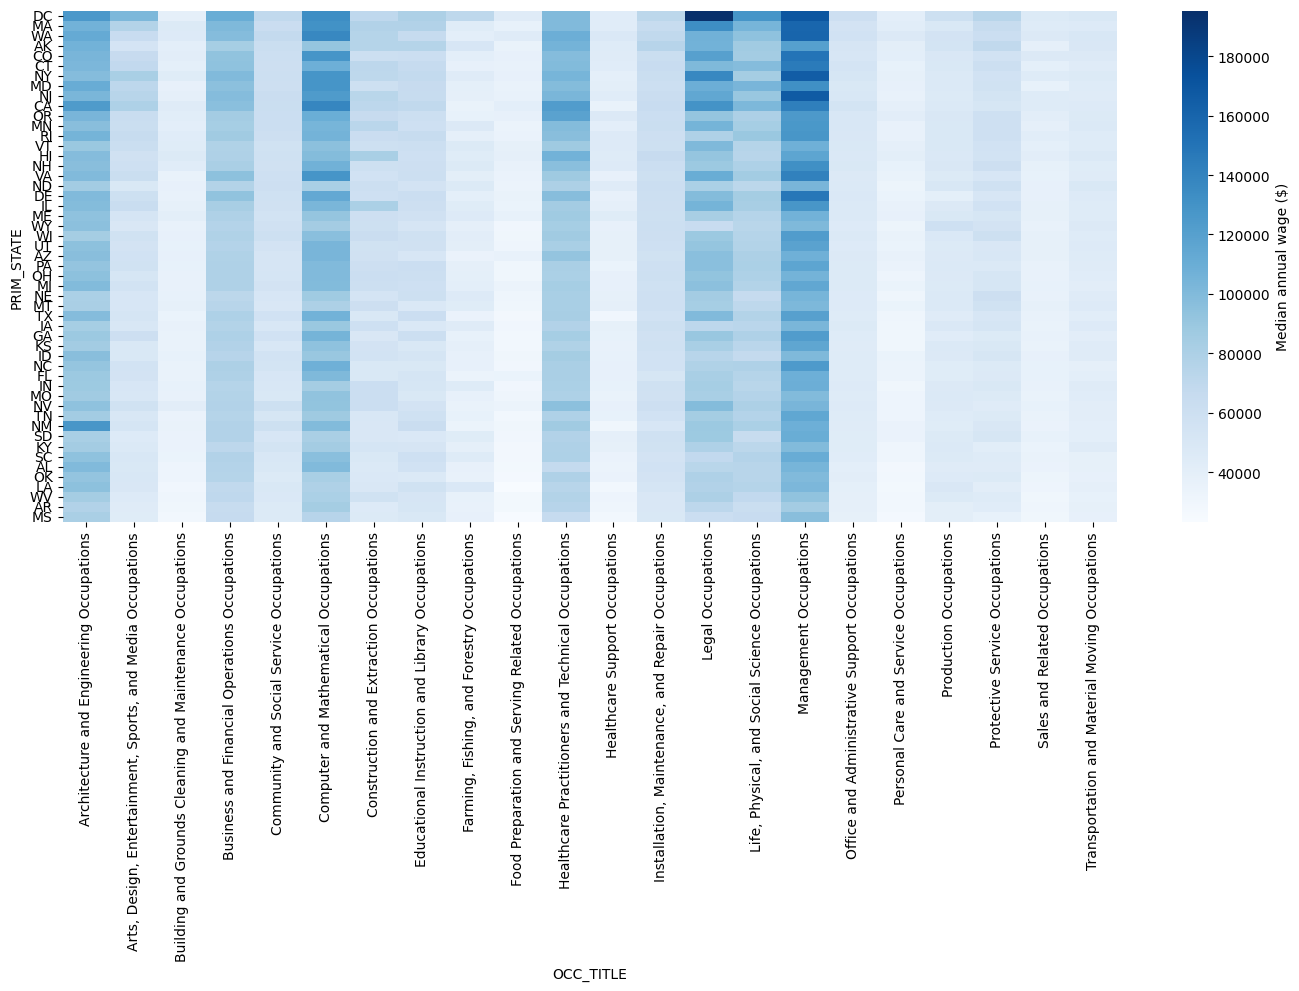

In [11]:
state_major = df[(df["AREA_TYPE"] == 2) & (df["O_GROUP"] == "major")]
pivot = state_major.pivot_table(index="PRIM_STATE", columns="OCC_TITLE", values="A_MEDIAN")

state_totals = df[
    (df["AREA_TYPE"] == 2) &
    (df["O_GROUP"] == "total")
].set_index("PRIM_STATE")["A_MEDIAN"]

state_order = state_totals.sort_values(ascending=False).index
pivot_sorted = pivot.reindex(state_order)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(pivot_sorted, cmap="Blues", cbar_kws={"label": "Median annual wage ($)"}, ax=ax)
plt.tight_layout()
plt.show()

### Correlation Heatmap

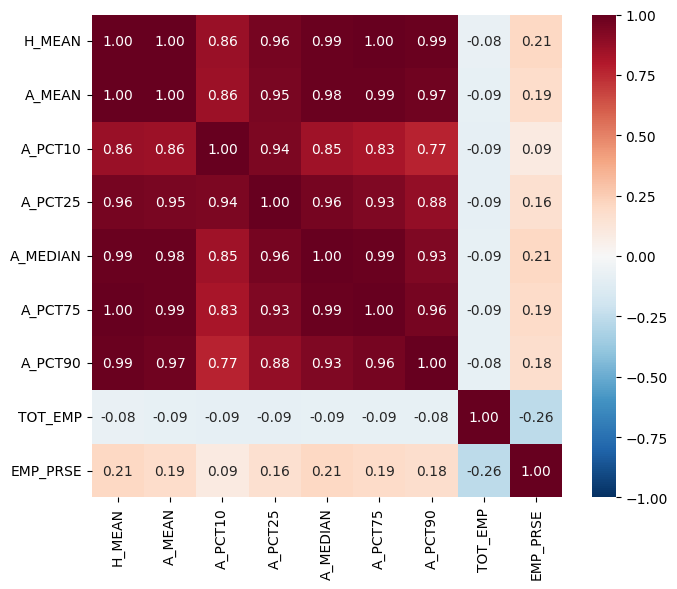

In [12]:
national_detailed = df[
    (df["AREA_TYPE"] == 1) &
    (df["O_GROUP"] == "detailed") &
    (df["I_GROUP"] == "cross-industry")
]

wage_cols = ["H_MEAN", "A_MEAN", "A_PCT10", "A_PCT25", "A_MEDIAN", "A_PCT75", "A_PCT90", "TOT_EMP", "EMP_PRSE"]
corr = national_detailed[wage_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax)
plt.tight_layout()
plt.show()

## Data Quality & Relationship Analysis

Additional checks to support the EDA write-up: duplicate keys, missingness on the slice
actually used for analysis, outlier/skewness checks on wage and employment, and a
cross-dataset validation against O*NET Job Zones.

### Duplicate Checks

In [13]:
print("Fully duplicated rows:", df.duplicated().sum())

key_oews = ["AREA", "NAICS", "OCC_CODE", "OWN_CODE"]
print("Duplicated (AREA, NAICS, OCC_CODE, OWN_CODE) keys:", df.duplicated(subset=key_oews).sum(), "/", len(df))

print("\nNational/detailed/cross-industry slice rows:", len(national_detailed))
print("Duplicated OCC_CODE within that slice:", national_detailed["OCC_CODE"].duplicated().sum())

Fully duplicated rows: 0
Duplicated (AREA, NAICS, OCC_CODE, OWN_CODE) keys: 3541 / 413527

National/detailed/cross-industry slice rows: 830
Duplicated OCC_CODE within that slice: 0


### Missing Values on the Analysis-Relevant Slice

The full-file missingness reported earlier includes rows from every aggregation level.
Once filtered to national/detailed/cross-industry — the slice actually used for
analysis — missingness is substantially lower.

In [14]:
cols_check = ["TOT_EMP", "EMP_PRSE", "H_MEAN", "A_MEAN", "MEAN_PRSE",
              "H_PCT10", "H_PCT25", "H_MEDIAN", "H_PCT75", "H_PCT90",
              "A_PCT10", "A_PCT25", "A_MEDIAN", "A_PCT75", "A_PCT90"]

national_detailed[cols_check].isna().mean().mul(100).round(2)

TOT_EMP      0.00
EMP_PRSE     0.00
H_MEAN       6.99
A_MEAN       0.60
MEAN_PRSE    0.00
H_PCT10      6.99
H_PCT25      6.99
H_MEDIAN     6.99
H_PCT75      6.99
H_PCT90      6.99
A_PCT10      0.60
A_PCT25      0.60
A_MEDIAN     0.60
A_PCT75      0.60
A_PCT90      0.60
dtype: float64

### Outlier Detection & Skewness — Wages and Employment

IQR-based outlier check on `A_MEDIAN`, plus a skewness comparison before/after a
`log1p` transform for both `A_MEDIAN` and `TOT_EMP`. High earners here are legitimate
(e.g. physician specialties), not data errors — the fix is a transform, not removal.

In [15]:
import numpy as np

vals = national_detailed["A_MEDIAN"].dropna()
q1, q3 = vals.quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = vals[(vals < lo) | (vals > hi)]

print(f"Q1={q1}, Q3={q3}, IQR={iqr}, bounds=({lo:.0f}, {hi:.0f})")
print(f"Outliers: {len(outliers)} / {len(vals)} ({len(outliers) / len(vals) * 100:.1f}%)")
print("\nTop 5 highest A_MEDIAN occupations:")
print(national_detailed.nlargest(5, "A_MEDIAN")[["OCC_TITLE", "A_MEDIAN"]])

print("\nSkewness of A_MEDIAN:", vals.skew())
print("Skewness of log1p(A_MEDIAN):", np.log1p(vals).skew())

emp = national_detailed["TOT_EMP"].dropna()
print("\nSkewness of TOT_EMP:", emp.skew())
print("Skewness of log1p(TOT_EMP):", np.log1p(emp).skew())

Q1=47120.0, Q3=81490.0, IQR=34370.0, bounds=(-4435, 133045)
Outliers: 57 / 825 (6.9%)

Top 5 highest A_MEDIAN occupations:
               OCC_TITLE  A_MEDIAN
564   Pediatric Surgeons  559030.0
549        Cardiologists  496010.0
559         Radiologists  420860.0
565  Surgeons, All Other  414010.0
548    Anesthesiologists  391490.0

Skewness of A_MEDIAN: 4.15185558994008
Skewness of log1p(A_MEDIAN): 1.2128399172575388

Skewness of TOT_EMP: 5.222972381541782
Skewness of log1p(TOT_EMP): 0.05807042129592238


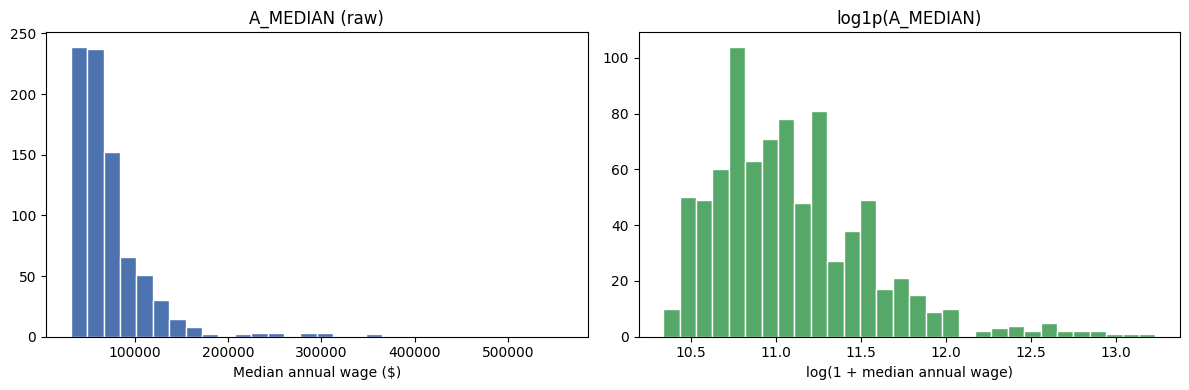

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(vals, bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("A_MEDIAN (raw)")
axes[0].set_xlabel("Median annual wage ($)")

axes[1].hist(np.log1p(vals), bins=30, color="#55A868", edgecolor="white")
axes[1].set_title("log1p(A_MEDIAN)")
axes[1].set_xlabel("log(1 + median annual wage)")

plt.tight_layout()
plt.show()

### Cross-Dataset: O*NET Job Zone vs. OEWS Wage

Validates that O*NET's Job Zone (occupation preparation level) is a meaningful feature by
checking whether it tracks real wage differences in OEWS. Requires joining on `OCC_CODE` /
`O*NET-SOC Code` after stripping O*NET's `.00`/`.01` detail suffix.

In [17]:
job_zones = pd.read_csv(
    Path("C:/Users/patel/Python/db_30_3_text/Job Zones.txt"), sep="\t", dtype=str, low_memory=False
)
job_zones["Job Zone"] = pd.to_numeric(job_zones["Job Zone"], errors="coerce")
job_zones["OCC_CODE"] = job_zones["O*NET-SOC Code"].str[:7]

wage_by_code = national_detailed.set_index("OCC_CODE")["A_MEDIAN"]
onet_to_oews = job_zones.merge(wage_by_code.rename("A_MEDIAN"), left_on="OCC_CODE", right_index=True, how="left")

print("Merge match rate:", round(onet_to_oews["A_MEDIAN"].notna().mean() * 100, 1), "%")
onet_to_oews.groupby("Job Zone")["A_MEDIAN"].agg(["mean", "median", "std", "count"])

Merge match rate: 96.1 %


,mean,median,std,count
Job Zone,,,,
2,49550.660377,47150.0,13420.716643,318
3,67880.295567,63190.0,21834.252701,203
4,97059.534884,92100.0,31153.381940,215
5,136296.357616,100330.0,90196.962251,151


### Many-to-One Join Check: O*NET-SOC Code → OCC_CODE

O*NET splits some SOC codes into multiple detailed occupations (`.00`, `.01`, ...) that
OEWS reports as a single 6-digit code. This quantifies how often that collapsing happens,
which bounds how granular any O*NET-to-OEWS comparison can be.

In [18]:
dupe_map = onet_to_oews.groupby("OCC_CODE")["O*NET-SOC Code"].nunique()

print("OCC_CODEs with >1 O*NET-SOC Code mapped to them:", (dupe_map > 1).sum(), "/", len(dupe_map))
print("Max O*NET-SOC codes mapped to a single OCC_CODE:", dupe_map.max())

OCC_CODEs with >1 O*NET-SOC Code mapped to them: 67 / 798
Max O*NET-SOC codes mapped to a single OCC_CODE: 9
